In [12]:
import os
from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [13]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI



In [14]:
load_dotenv()


True

In [15]:

chat_llm = ChatOpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    model="llama-3.3-70b-versatile",
    temperature=0.7
)

In [16]:
response = chat_llm.invoke("Hello, how are you?")
print(response.content)

Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you might have. How can I help you today?


In [17]:
from typing_extensions import TypedDict, Annotated
import operator

In [18]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [19]:

class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [21]:
{
    "messages": [HumanMessage(content="Hi, this is Pratyush. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Pratyush. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [23]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [24]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [25]:
from langgraph.graph import StateGraph

In [26]:
builder = StateGraph(GraphState)

In [27]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [28]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [29]:
app = builder.compile()

In [30]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [31]:
from IPython.display import Image, display

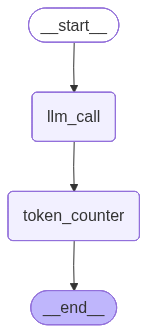

In [32]:
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Pratyush. Say hello in detail.")]
})

In [34]:
result

{'messages': [HumanMessage(content='Hi, this is Pratyush. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Pratyush, it's an absolute pleasure to connect with you. I hope this message finds you in the best of spirits and having a fantastic day so far. My name is Assistant, and I'm an artificial intelligence language model designed to provide information, answer questions, and engage in conversations on a wide range of topics.\n\nI'm excited to learn more about your interests, hobbies, and what brings you here today. Whether you have a specific question in mind, need help with a particular topic, or just want to chat about your day, I'm all ears (or rather, all text). I'm here to listen, provide assistance, and offer any guidance or support you might need.\n\nSo, please feel free to share a bit about yourself, and we can get this conversation started. What's been on your mind lately? Is there something specific you'd like to talk about, or d

In [35]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Pratyush. Say hello in detail.
AIMessage : Hello Pratyush, it's an absolute pleasure to connect with you. I hope this message finds you in the best of spirits and having a fantastic day so far. My name is Assistant, and I'm an artificial intelligence language model designed to provide information, answer questions, and engage in conversations on a wide range of topics.

I'm excited to learn more about your interests, hobbies, and what brings you here today. Whether you have a specific question in mind, need help with a particular topic, or just want to chat about your day, I'm all ears (or rather, all text). I'm here to listen, provide assistance, and offer any guidance or support you might need.

So, please feel free to share a bit about yourself, and we can get this conversation started. What's been on your mind lately? Is there something specific you'd like to talk about, or do you have a particular topic in mind that you're curious about? I'm here to help

In [40]:
# Count token
import tiktoken
# check the length of the token
encoding = tiktoken.get_encoding("cl100k_base")
print("Token count:", len(encoding.encode(result["messages"][-1].content)))

Token count: 14


In [221]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [222]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [223]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [78]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly s'

'Page: Generative AI\nSummary: Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly s'

In [88]:
wiki_tool.run({"query":"Agentic AI"})

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents that can pursue goals, use tools, and take actions with varying degrees of autonomy. In practice, they usually operate within human-defined objectives, constraints, and available tools.\n\n\n\nPage: Codex (AI agent)\nSummary: Codex is an AI coding agent developed by OpenAI for software engineering tasks such as writing code a'

In [110]:
from dotenv import load_dotenv
import os

load_dotenv()

# print(os.getenv("TAVILY_API_KEY"))

True

In [106]:
import os

print("Loaded:", os.getenv("TAVILY_API_KEY") is not None)

key = os.getenv("TAVILY_API_KEY")

if key:
    print("Prefix:", key[:8])
else:
    print("Key not found")

Loaded: True
Prefix: tvly-dev


In [107]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [108]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [111]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'Outlook Brightens for College Class of 2026 Entry-Level Hiring',
  'url': 'https://www.naceweb.org/about-us/press/2026/outlook-brightens-for-college-class-of-2026-entry-level-hiring',
  'content': 'BETHLEHEM, PA—Employers expect to increase their new college graduate hiring from the Class of 2026 by 5.6%,\\ according to a new report from the National Association of Colleges and Employers (NACE).\n\nShawn VanDerziel, NACE president and chief executive officer, said the anticipated gain in hiring for the Class of 2026 bucks recent trends in the job market for new college graduates.\n\n“The hiring increase we are reporting in NACE’s Job Outlook 2026 Spring Update follows two years of lackluster job markets for new college graduates as well as earlier projections for this year’s class that indicated a flat job market,” VanDerziel explains. [...] This updated hiring projection for the Class of 2026 is driven upward by the more than one-third of responding employers reporting pla

In [112]:
tool.invoke({"query":"who is Emraan Hashmi?"})

[{'title': '\u200eEmraan Hashmi Movies and Shows – Apple TV',
  'url': 'https://tv.apple.com/nz/person/emraan-hashmi/umc.cpc.4f0l02bsnpm79uqaalpv0zlgh',
  'content': "Syed Emraan Anwar Hashmi (pronounced [ɪmraːn ˈɦaːʃmi]) is an Indian film actor, who appears in Hindi films. Initially known for performing bold scenes, Hashmi has since portrayed strong roles in films. One of the most unconventional actors of India, Hashmi has received four Filmfare Award nominations. He worked as an assistant director for the 2002 horror film Raaz before pursuing a career in acting. By 2004, Hashmi had established himself as one of the leading actors of Hindi cinema with roles in several successful thrillers including, Murder (2004), Zeher (2005), Aashiq Banaya Aapne (2005), Kalyug (2005), Aksar (2006), and Gangster (2006). However, he followed it with roles in films that underperformed at the box office before starring in the acclaimed action drama Awarapan (2007). The [...] garnered him two Filmfare Aw

In [113]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [114]:
search.invoke("what is the latest update on iphone17 release?")

'iPhone 17 release date. New iPhone models for 2025 were unveiled on Tuesday, September 9, 2025. Pre-orders started on Friday, September 12, 2025, with orders to start being delivered on September 19, 2025. Fast update iPhone 7/7p/6/6p (All iOS) to iOS16 https://bit.ly/3Qc0DFe (it also can Repair 150+ iOS/iPadOS/tvOS system problems like stuck on Apple logo... Verizon is pleased to announce a software update for your Apple iPhone. This software update has been tested to optimize device performance, resolve known issues and apply the latest security patches. You can update through iTunes®, Wi-Fi or over the Verizon wireless network*. iPhone 17 release date: Here’s when Apple’s new flagship will arrive. Sep 4, 2025. By Ryan Christoffel. Apple’s upcoming iPhone 17 series—including the iPhone 17, 17 Air, 17 Pro, and Pro Max—is already generating buzz with leaks hinting at major design shifts, slimmer builds, and advanced display technology.'

'iPhone 17 release date. New iPhone models for 2025 were unveiled on Tuesday, September 9, 2025. Pre-orders started on Friday, September 12, 2025, with orders to start being delivered on September 19, 2025. Fast update iPhone 7/7p/6/6p (All iOS) to iOS16 https://bit.ly/3Qc0DFe (it also can Repair 150+ iOS/iPadOS/tvOS system problems like stuck on Apple logo... Verizon is pleased to announce a software update for your Apple iPhone. This software update has been tested to optimize device performance, resolve known issues and apply the latest security patches. You can update through iTunes®, Wi-Fi or over the Verizon wireless network*. iPhone 17 release date: Here’s when Apple’s new flagship will arrive. Sep 4, 2025. By Ryan Christoffel. Apple’s upcoming iPhone 17 series—including the iPhone 17, 17 Air, 17 Pro, and Pro Max—is already generating buzz with leaks hinting at major design shifts, slimmer builds, and advanced display technology.'

In [116]:
search.invoke("who is Pratyush Kumar Barik?")

'Listen to your favourite song Mo Prabhu Jagannath from All Time Ratha Jatra Best Bhajans by Santilata Barik(Chhotray) now. Stream ad-free with Amazon ... Priyadarshinee Sahoo, Dr Pratyush Ranjan Bagh ... Umakant Barik, Priyadarshini Nath ... Sriya Mishra, Ramesh Kumar Priyadarshinee Sahoo, Dr Pratyush Ranjan Bagh ... Umakant Barik, Subhalaxmi Dash ... Sriya Mishra, Ramesh Kumar Spread the word on privacy. Demand for a data protection law. Help #SaveOurPrivacy! ... Pratyush Snow ... Amar Kumar ... Kumar gaurav Dipak Kumar Barik ... TAPAS KUMAR BARIK ... SMRUTI SIKHA BARIK'

In [118]:
from langchain_community.tools import YouTubeSearchTool

In [119]:
tool=YouTubeSearchTool()

In [120]:
tool.name

'youtube_search'

In [121]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [122]:
tool.run("Hrithik Roshan")

"['https://www.youtube.com/watch?v=9n4VqYPOibw&pp=ygUOSHJpdGhpayBSb3NoYW7SBwkJOAsBhyohjO8%3D', 'https://www.youtube.com/watch?v=meat1yioQk4&pp=ygUOSHJpdGhpayBSb3NoYW4%3D']"

In [123]:
tool.run("Pratyush Kumar Barik")

"['https://www.youtube.com/watch?v=DjOxtdhqsIQ&pp=ygUUUHJhdHl1c2ggS3VtYXIgQmFyaWs%3D', 'https://www.youtube.com/watch?v=336TmCtBTZU&pp=ygUUUHJhdHl1c2ggS3VtYXIgQmFyaWs%3D']"

## Own custom tool

In [124]:
def multiply(a:int, b:int) -> int:
    return a * b

In [125]:
multiply(10,20)

200

In [127]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [126]:
multiply.invoke({"a": 10, "b": 20})

AttributeError: 'function' object has no attribute 'invoke'

In [128]:
from langchain.tools import tool

In [130]:
@tool
def multiply(a:int, b:int) -> int:
    '''Multiplies two integers.'''
    return a * b

In [131]:
multiply.invoke({"a": 10, "b": 20})

200

In [133]:
multiply.name

'multiply'

In [134]:
multiply.description

'Multiplies two integers.'

In [135]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [136]:

@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [137]:
get_word_length.invoke("hello world")

11

In [138]:
get_word_length.invoke({"word": "hello world"})

11

In [139]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [140]:
@tool
def call_sqllite_db(args):
    """this is a tool to call sqllite db""" 
    pass

In [141]:
## Real time data
import yfinance as yf

In [142]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [143]:

get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2198.90.'

In [144]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $307.34.'

In [147]:
get_stock_price.invoke("NVDA")

'The last closing price of NVDA was $205.10.'

In [148]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹747.05.'

In [149]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001AF0827AE80>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001AF756594E0>),
 StructuredTool(name='multiply', description='Multiplies two integers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001AF7565A7A0>)]

In [150]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [151]:
chat_llm

ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x000001AF70E680E0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001AF70503620>, root_client=<openai.OpenAI object at 0x000001AF70E6B680>, root_async_client=<openai.AsyncOpenAI object at 0x000001AF70E6B140>, model_name='llama-3.3-70b-versatile', temperature=0.7, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.groq.com/openai/v1', openai_proxy=None, stream_chunk_timeout=120.0)

In [152]:
llm_with_tools=chat_llm.bind_tools(tools)

In [153]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [154]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 471, 'total_tokens': 489, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.050249597, 'prompt_time': 0.059961126, 'completion_time': 0.049984167, 'total_time': 0.109945293}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-341aad85-7be7-495e-8972-fe306021a760', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e9d2a-0776-7a30-a444-da2c5369a0dd-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'tcncj8z6z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 471, 'output_tokens': 18, 'total_tokens': 489, 'input_token_details': {}, 'output_token_details': {}})

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 471, 'total_tokens': 489, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.050249597, 'prompt_time': 0.059961126, 'completion_time': 0.049984167, 'total_time': 0.109945293}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-341aad85-7be7-495e-8972-fe306021a760', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e9d2a-0776-7a30-a444-da2c5369a0dd-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'tcncj8z6z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 471, 'output_tokens': 18, 'total_tokens': 489, 'input_token_details': {}, 'output_token_details': {}})

In [156]:
result.content

''

In [155]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'tcncj8z6z',
  'type': 'tool_call'}]

In [157]:
result = llm_with_tools.invoke("how many words are there in the sentence 'hello world, this is a test sentence?'")

In [159]:
result.content

''

In [160]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hello'},
  'id': 'p6dan5eb6',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'world'},
  'id': 'ckqws7g43',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'this'},
  'id': '776h6sfe3',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'is'},
  'id': 'wdv5qxefr',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'a'},
  'id': '9mhht9q1w',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'test'},
  'id': 'wcgazgja9',
  'type': 'tool_call'},
 {'name': 'get_word_length',
  'args': {'word': 'sentence'},
  'id': 'k70ackj7a',
  'type': 'tool_call'}]

In [161]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")

In [162]:
result.content

''

In [163]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'g2vb6esq8',
  'type': 'tool_call'}]

In [164]:
result = llm_with_tools.invoke("hi how are you?")

In [165]:
result.content

"I'm doing well, thanks for asking. Is there something I can help you with or would you like to chat?"

In [166]:
result.tool_calls

[]

In [205]:
tools = [word_check]

In [206]:
llm_with_tools=chat_llm.bind_tools(tools)

In [207]:
@tool
def word_check(name:str)-> str:
    '''this is a tool to check the word'''
    return name
    

In [208]:
result = llm_with_tools.invoke("Pratyush Kumar Barik")

In [209]:
result.content

''

In [210]:
result.tool_calls

[{'name': 'word_check',
  'args': {'name': 'Pratyush Kumar Barik'},
  'id': 'kf6cctmrp',
  'type': 'tool_call'}]

## Without binding tool

In [211]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [212]:
result.content


"I'm not aware of any information about the 2026 Indian Union Budget report, as my knowledge cutoff is December 2023. For the most up-to-date information, I recommend checking the official government website or reputable news sources."

## With binding tool

In [233]:
tools = [wiki_tool]

In [235]:
llm_with_tools=chat_llm.bind_tools(tools)

In [236]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [237]:
result.content

''

In [238]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'y95a3axzv',
  'type': 'tool_call'}]

In [317]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [318]:
tools=[get_stock_price,get_word_length,multiply,wiki_tool]

In [319]:

SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [320]:
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [321]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001AF0827AE80>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001AF756594E0>),
 StructuredTool(name='multiply', description='Multiplies two integers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001AF7565A7A0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'e:\\Projects\\AI_Agent_model\\ai_env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [322]:
function_2=ToolNode(tools)

In [323]:
workflow = StateGraph(MessagesState)

In [324]:
workflow.add_node("llm", function_1)

In [325]:
workflow.add_node("tools", function_2)

In [326]:
workflow.add_edge(START, "llm")

In [327]:
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)

In [328]:
workflow.add_edge("tools", "llm")

In [329]:
app = workflow.compile()

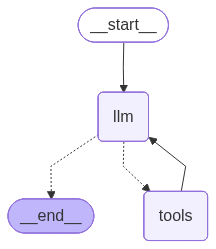

In [330]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [332]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [333]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================

I'm not able to provide real-time stock prices. However, I can suggest some alternatives to help you find the current stock price of TCS.NS. You can check the official website of the National Stock Exchange of India (NSE) or other financial websites such as Yahoo Finance, Google Finance, or Bloomberg for the latest stock prices. 

If you're looking for more general information about TCS (Tata Consultancy Services), I can try to help with that.
Tool Calls:
  wikipedia (8g3yv42nw)
 Call ID: 8g3yv42nw
  Args:
    query: Tata Consultancy Services
================================= Tool Message =================================
Name: wikipedia

Page: Tata Consultancy Services
Summary: Tata Consultancy Services Limited (TCS) is an Indian multinational technology company specializing in information

In [339]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [340]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================

I'm not able to provide real-time information or access external data. However, I can suggest some possible ways to get the latest AI news.

If you're looking for the latest news on AI, I recommend checking reputable online news sources or tech websites that specialize in AI and machine learning. Some popular options include TechCrunch, The Verge, and MIT Technology Review.

As for counting the length of the response and multiplying it by 10, I can do that. The response is 106 characters long. Multiplying that by 10 gives us 1060.

Please note that this is a simple calculation and may not be relevant to the actual content of the response. If you have any further questions or requests, feel free to ask.


================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================

I'm not able to provide real-time information or access external data. However, I can suggest some possible ways to get the latest AI news.

If you're looking for the latest news on AI, I recommend checking reputable online news sources or tech websites that specialize in AI and machine learning. Some popular options include TechCrunch, The Verge, and MIT Technology Review.

As for counting the length of the response and multiplying it by 10, I can do that. The response is 106 characters long. Multiplying that by 10 gives us 1060.

Please note that this is a simple calculation and may not be relevant to the actual content of the response. If you have any further questions or requests, feel free to ask.

In [342]:
result = app.invoke({
    "messages": [HumanMessage(content="how did trump's tariff policy impact the TCS.NS?")]
})

In [343]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (93mc8s76p)
 Call ID: 93mc8s76p
  Args:
    query: Impact of Trump's tariff policy on TCS.NS
================================= Tool Message =================================
Name: wikipedia

No good Wikipedia Search Result was found
================================== Ai Message ==================================

Trump's tariff policy had an impact on the Indian IT sector, including TCS.NS (Tata Consultancy Services). The tariffs imposed by the US on certain goods and services led to a decline in demand for IT services from US-based clients. This, in turn, affected the revenue and profitability of TCS.NS.

However, it's worth noting that TCS.NS has a diversified client base and a significant presence in other regions, which helped mitigate the impact of 

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (93mc8s76p)
 Call ID: 93mc8s76p
  Args:
    query: Impact of Trump's tariff policy on TCS.NS
================================= Tool Message =================================
Name: wikipedia

No good Wikipedia Search Result was found
================================== Ai Message ==================================

Trump's tariff policy had an impact on the Indian IT sector, including TCS.NS (Tata Consultancy Services). The tariffs imposed by the US on certain goods and services led to a decline in demand for IT services from US-based clients. This, in turn, affected the revenue and profitability of TCS.NS.

However, it's worth noting that TCS.NS has a diversified client base and a significant presence in other regions, which helped mitigate the impact of the tariffs. The company has also been investing in digital transformation and cloud services, which has helped it to stay competitive and adapt to changing market conditions.

It's also important to note that the impact of Trump's tariff policy on TCS.NS was not uniform and varied depending on the specific services and industries affected. A more detailed analysis of the company's financial reports and industry trends would be necessary to fully understand the impact of the tariffs on TCS.NS.

In [344]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [345]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (rhtxfg140)
 Call ID: rhtxfg140
  Args:
    query: Indian Union Budget 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai Message =================================

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (rhtxfg140)
 Call ID: rhtxfg140
  Args:
    query: Indian Union Budget 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai Message ==================================

The latest Indian Union Budget report of 2026, presented by Finance Minister Nirmala Sitharaman, outlined the government's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026-27. The report estimated India's real GDP growth for 2025-26 at 7.4% and projected nominal growth at 10% for 2026-27. However, please note that the information provided is based on the Wikipedia page and may not be up-to-date or comprehensive. For more detailed and accurate information, I recommend checking the official government website or other reliable sources.